# Sistem za preporuku algoritama i struktura podataka

Tamara Cvjetković, SV48-2022

Datum: 18.10.2025.

_Napomena: pretpostavlja se da su artefakti već generisani (trening je već pokrenut)_

Sadržaj:
- Konfiguracija (config)
- Skup podataka (pregled) i distribucija klasa
- Pretprocesiranje (šta radimo i zašto)
- Modeli (NB, KNN, SBERT), i ‘what-if’ parametri
- Evaluacija: metrike i grafici (confusion matrix, bar predikcija)
- Kako dobiti preporuku algoritma ili strukture podataka?
- Kako pokrenuti kompletan trening iz terminala (dodatno)
- Zaključak


## 1) Konfiguracija (config)
Sva bitna konfiguracija se nalazi u `src/config.py` :
- putanje (korijen projekta, skup podataka, izlazi predviđanja, artefakti)
- podešavanja parametara (model, pretprocesiranje..)

## 2) Skup podataka (pregled) i distribucija klasa
Podaci se učitavaju iz `config.DATASET_PATH`.

Kolone: `opis_problema` (tekst) i `klasa` (ime algoritma/strukture).


In [7]:
from src import config
import pandas as pd

df = pd.read_csv(config.DATASET_PATH)
df = df[['opis_problema', 'klasa']]
print('Broj redova:', len(df))
df.sample(10)


Broj redova: 714


,opis_problema,klasa
667,Moram da pronađem medijan u toku obrade,Heap
656,Moram da implementiram efikasno izvlačenje mak...,Heap
297,Kako da implementiram min ili max heap za prio...,PriorityQueue
446,Moram da implementiram lookup tabelu,HashMap
204,Treba mi algoritam sa optimalnom podsturkturom,DynamicProgramming
578,Kako da implementiram aggregate functions na s...,SegmentTree
503,Želim da implementiram expression evaluation,Stack
515,Moram da čuvam čvorove i veze između njih,Graph
575,Kako da održavam statistike na intervalima,SegmentTree
320,Kako da čuvam samo jedinstvene vrednosti,Set


In [4]:
# Distribucija klasa:
df['klasa'].value_counts().head(20)

klasa
Dijkstra              41
Backtracking          41
Graph                 41
HashMap               41
Queue                 41
PriorityQueue         41
Set                   41
DynamicProgramming    41
Heap                  41
DFS                   40
Array                 40
BinarySearch          40
QuickSort             40
Stack                 40
BFS                   40
SegmentTree           40
LinkedList            40
Name: count, dtype: int64

### Distribucija klasa
Grafik distribucije pomaže da vidimo balans klasa. Ako nisu balansirane, F1‑macro je bolja metrika od accuracy‑ja (tačnost).

#### Zašto?

accuracy = (tačne predikcije) / (ukupan broj predikcija)

Što slijedi da model može imati visok accuracy zbog predviđanja dominantne klase (npr. 95 primjera za Dijkstru, 5 primjera za SegmentTree => visok accuracy, oko ~90%)

F1-macro računa skor (precision - broj tačnih među predviđenim, recall - broj pronađenih od svih postojećih, F1 - sredina prva dva) za svaku klasu posebno, i tek onda uzima prosjek.

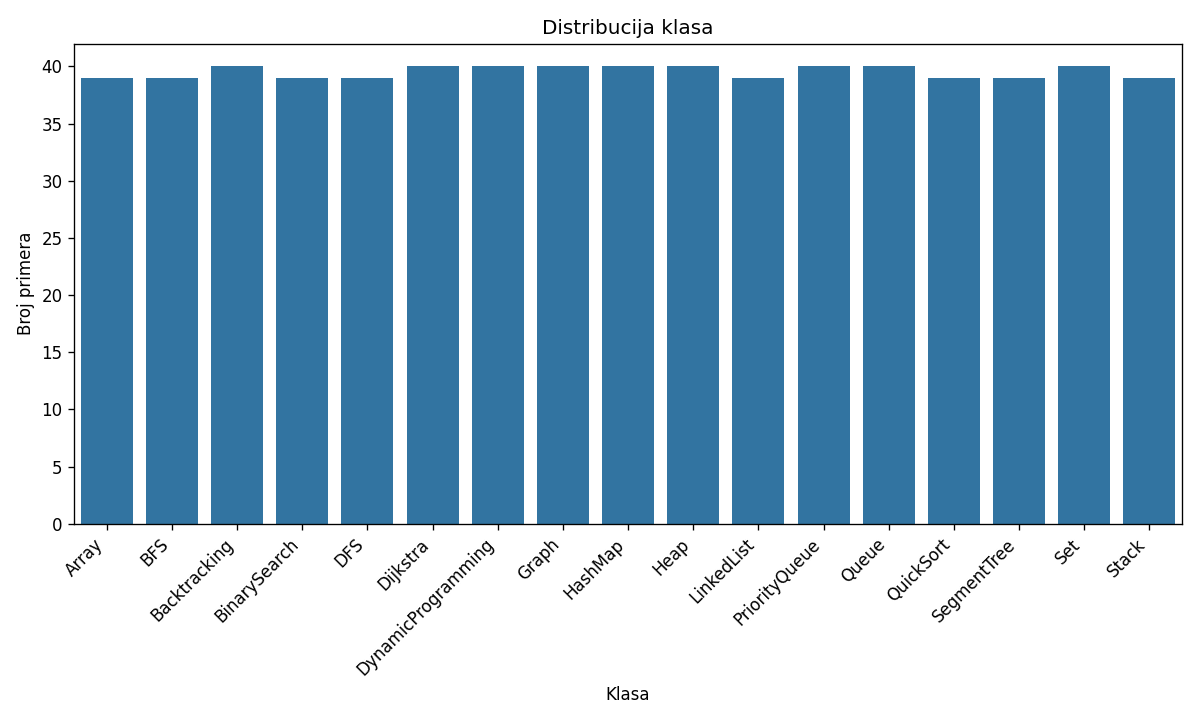

In [10]:
from IPython.display import Image, display
from src.visualize import plot_class_distribution

dist_path = config.OUTPUT_DIR / 'class_distribution.png'
if dist_path.exists():
    display(Image(filename=str(dist_path)))
else:
    plot_class_distribution(df['klasa'].tolist(), dist_path)
    display(Image(filename=str(dist_path)))

## 3) Pretprocesiranje (šta radimo i zašto)

#### 3.1) Za NB/KNN (TF-IDF):
1. lowercase,
2. uklanjanje interpunkcije (zarezi, tačke, zagrade..) i cifara,
3. stopwords,
4. tokenizacija - razbijamo tekst na pojedinačne riječi,
5. TF‑IDF - pretvaramo tekst u numeričke vrijednosti (1-2 grama - "put", "najkraći put").

TD-IDF (Term Frequency - Inverse Docmument Frequency):
- **TF**: koliko često se riječ pojavljuje u dokumentu
- **IDF**: koliko je riječ "rijetka" u cijelom skupu dokumenata
- **TF-IDF**: TF × IDF → daje veću težinu specifičnim rečima, manju čestim

In [11]:
from src.preprocessing import clean_text

samples = [
    'Želim da pronađem najkraći put između dva ČVORA u grafu!!!',
    'Moram da održavam NAJVEĆI element (max-heap) nakon dodavanja/brisanja 123',
    'Treba mi struktura za brzu pretragu po ključu: npr. Hash Map?',
]
for s in samples:
    print(f'ORIGINAL: {s}')
    print(f'CLEANED : {clean_text(s)}')
    print('-'*60)


ORIGINAL: Želim da pronađem najkraći put između dva ČVORA u grafu!!!
CLEANED : želim pronađem najkraći put dva čvora grafu
------------------------------------------------------------
ORIGINAL: Moram da održavam NAJVEĆI element (max-heap) nakon dodavanja/brisanja 123
CLEANED : održavam najveći element max heap nakon dodavanja brisanja
------------------------------------------------------------
ORIGINAL: Treba mi struktura za brzu pretragu po ključu: npr. Hash Map?
CLEANED : treba struktura brzu pretragu ključu npr hash map
------------------------------------------------------------


#### 3.2) Za SBERT (Semantic Embeddings):
1. blago čišćenje (SBERT razumije kontekst i ignoriše šum),
2. SBERT tokenizer - specijalni tokenizer koji dijeli tekst na subword tokene
3. SBERT encoder - neuronska mreža koja tekst pretvara u semantički vektor
4. Normalizacija - vektori se skaliraju na jediničnu dužinu

Embedding je **numerička reprezentacija teksta** koja čuva semantičko značenje:
- Slične rečenice → slični vektori
- Različite rečenice → različiti vektori

Primjer:
- "Najkraći put između čvorova" => [0.23, -0.45, 0.67, ..., 0.12] (puno dimenzija)
- "Optimalna ruta u grafu" => [0.21, -0.43, 0.69, ..., 0.15] (slično kao prvo)
- "Dodaj element u listu" => [-0.67, 0.12, -0.34, ..., 0.89] (različito!)

## 4) Modeli i ‘what‑if’ parametri (objašnjenja)
### Naivni Bajes (TF‑IDF → MultinomialNB)
- Brzi, dobar baseline za tekst
- Pretvara tekst u brojeve (važnost) i računa vjerovatnoću da tekst pripada svakoj klais
- Parametri: n‑grami (1‑2 vs 1‑3), `min_df`, `max_df`.
  - Viši n‑grami mogu uhvatiti fraze (npr. "najkraći put"), ali povećavaju rizik od "prenaučenosti" na malom skupu.

### KNN (TF‑IDF → KNeighborsClassifier)
- Klasifikacija po sličnosti: gleda k najbližih susjeda u TF‑IDF prostoru.
- Pretvara tekst u brojeve, za novi tekst traži k najbližih sličnih primjera iz treninga
- `k`: manji k (npr. 1) je brži, ali osjetljiv na šum; veći k (npr. 7–9) je stabilniji, ali može "izravnati" razlike.
- "cosine" (metrika distance) je uobičajena kod TF‑IDF; ako biblioteka ne podržava, koristi se "minkowski".

### SBERT (Sentence‑BERT embedding → klasifikator LR/RF)
- Unaprijed istrenirani model koji pretvara rečenice u semantičke vektore (embedding), čuva značenje i kontekst.
- Klasifikator: podrazumijevano Logistička regresija (LR) - brza; alternativa Random Forest (RF) - otporan na greške u podacima, ali teži i sporiji.
- Normalizacija embeddinga - skaliramo vektore na istu dužinu radi bolje uporedivosti tekstova.
- Ograničenja: prvi put preuzimanje modela, izvrsavanje na CPU sporije od GPU

## 5) Evaluacija: metrike (accuracy, F1‑macro) i rezultati

In [14]:
import json
import pandas as pd

metrics_path = config.OUTPUT_DIR / 'metrics.json'
with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics = json.load(f)

df_metrics = pd.DataFrame(metrics).T
display(df_metrics)


,accuracy,f1_macro,best_k,classifier
naive_bayes,0.696296,0.69706,NaN,NaN
knn,0.659259,0.656459,1.0,NaN
sbert,0.644444,0.633844,NaN,logreg


### Confusion matrice i bar grafovi predikcija
- Confusion matrica: gdje model griješi (po klasama).
- Bar graf: koje klase model najčešće predviđa (možda "preferira" neke).

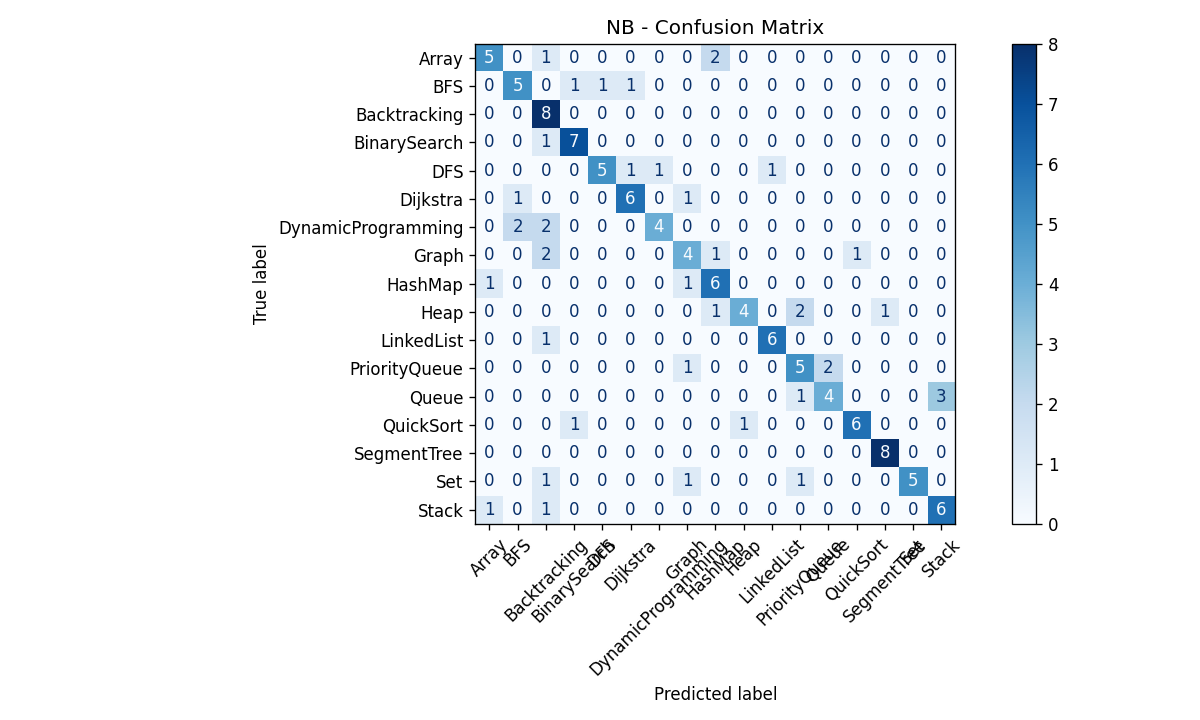

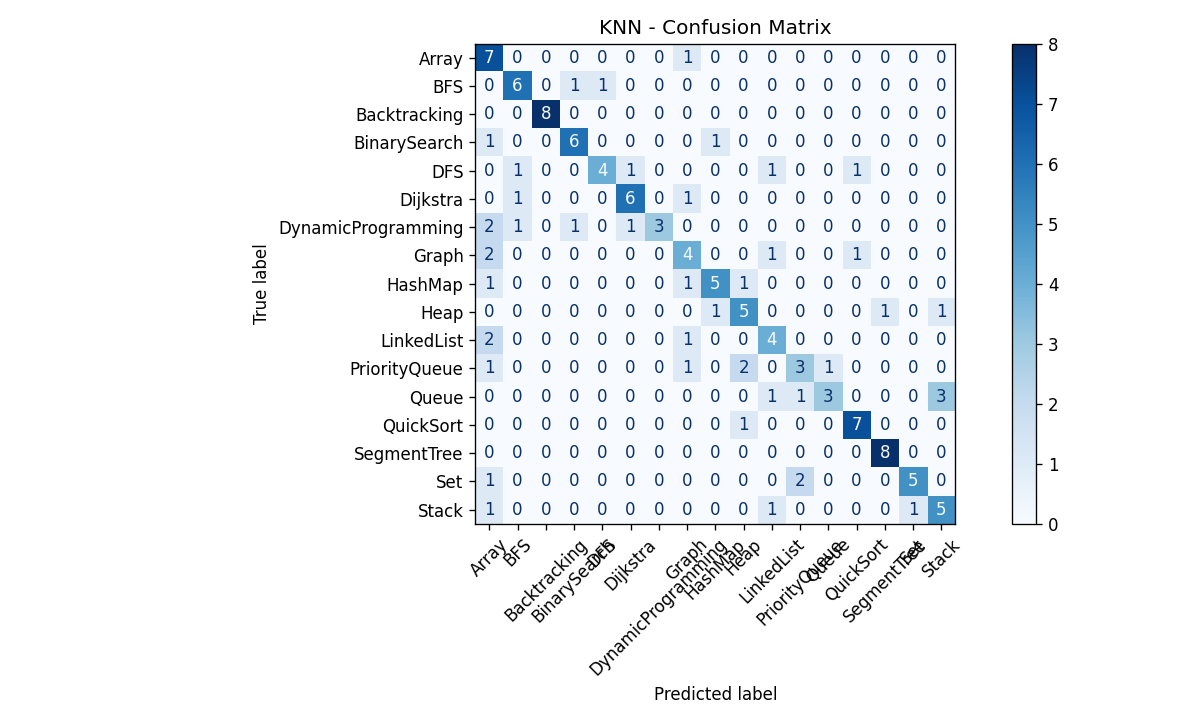

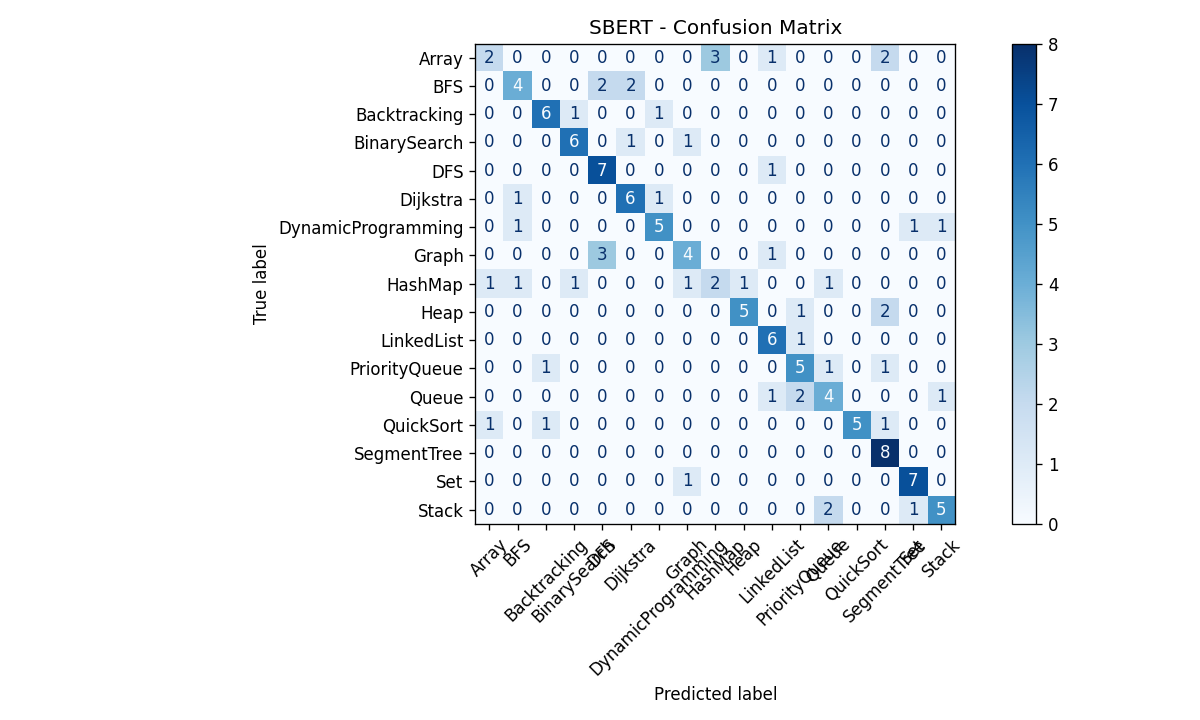

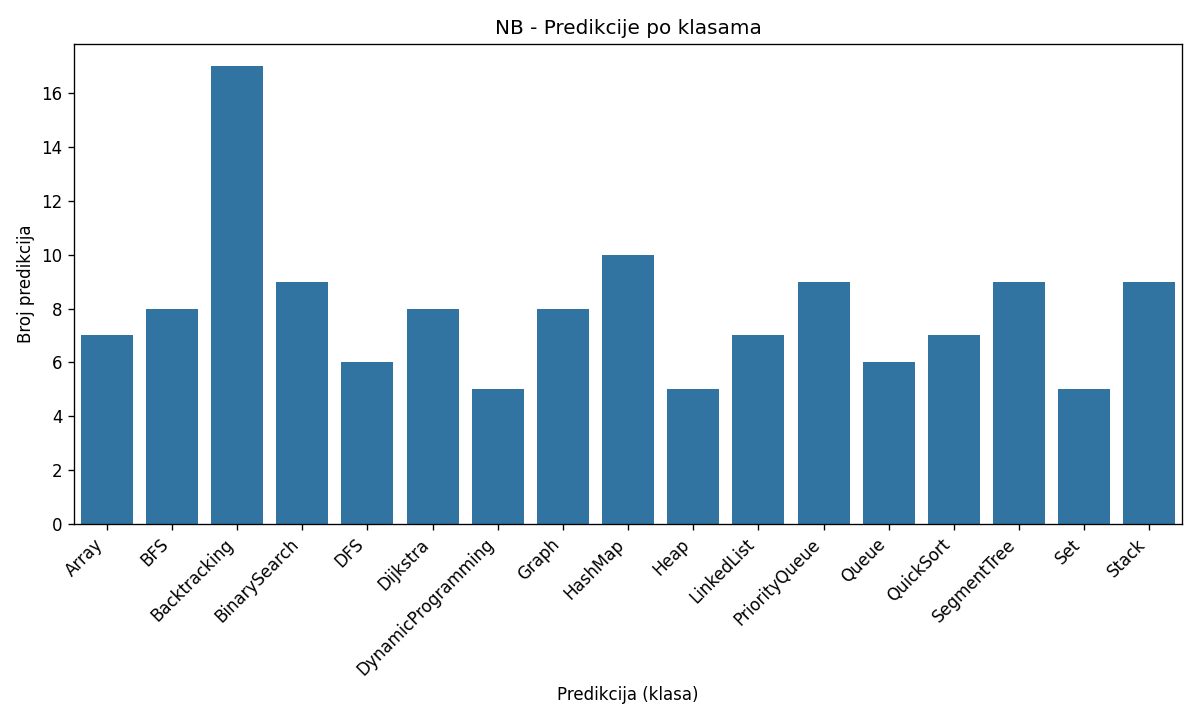

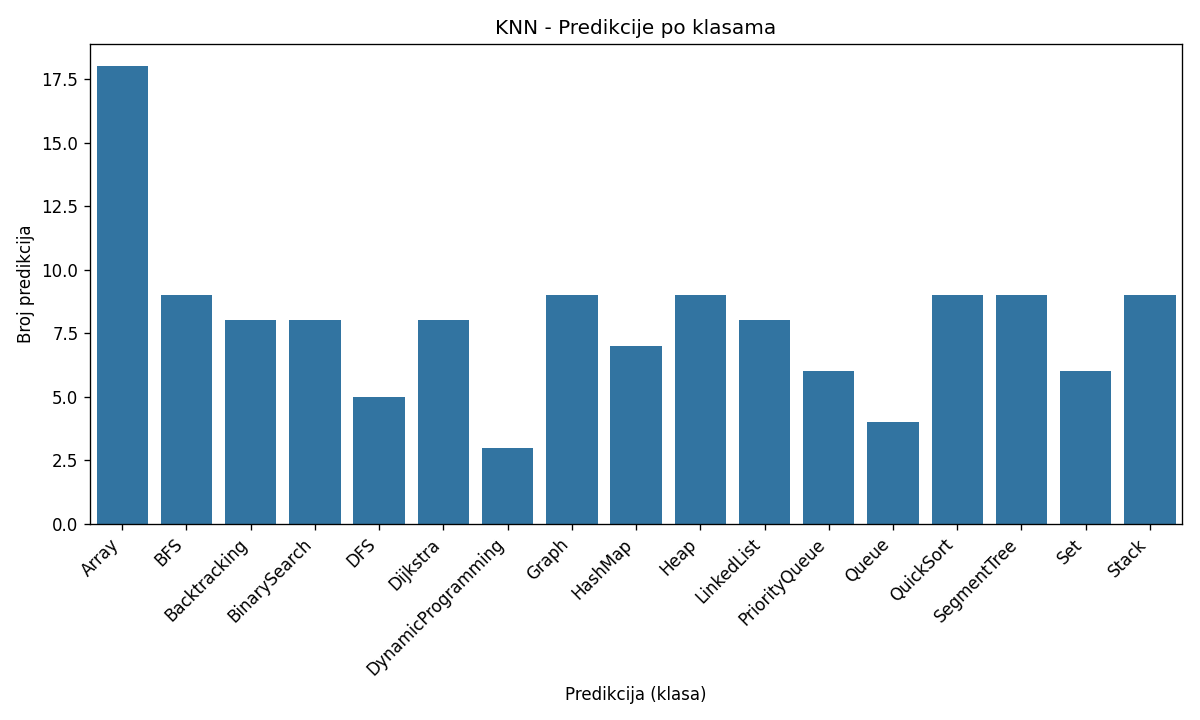

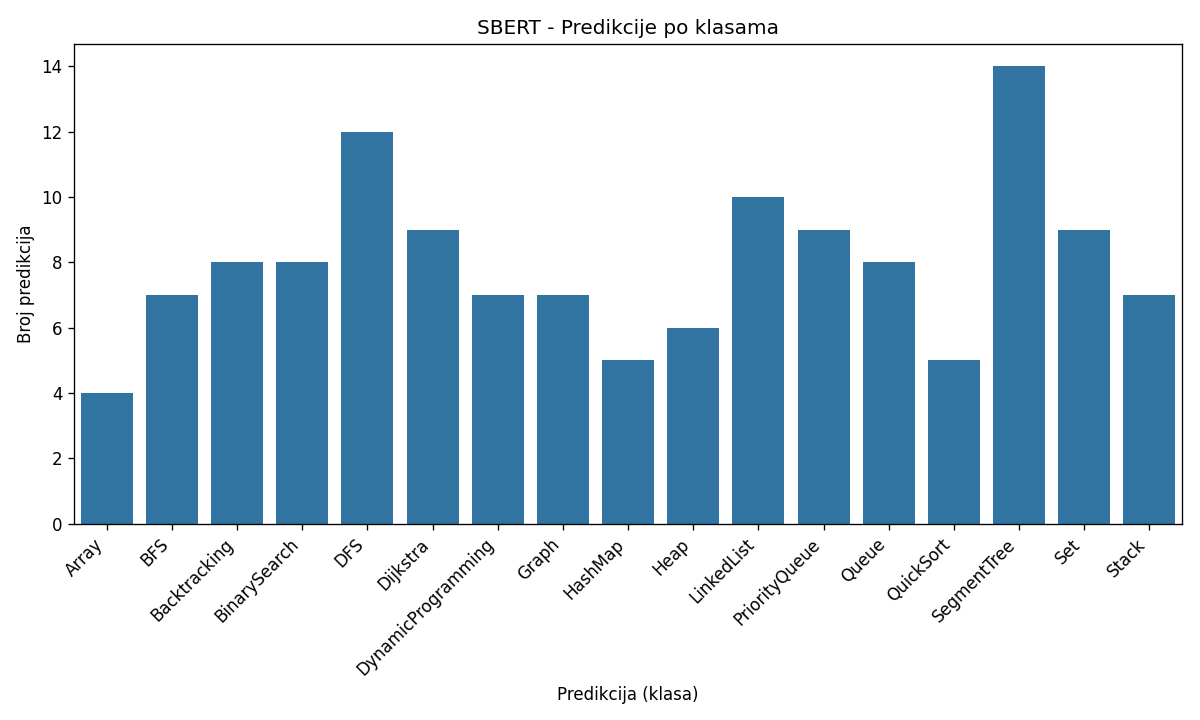

In [15]:
from IPython.display import Image, display
for name in ['nb', 'knn', 'sbert']:
    path = config.OUTPUT_DIR / f'{name}_confusion.png'
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'Confusion matrix ne postoji za: {name}')

for name in ['nb', 'knn', 'sbert']:
    path = config.OUTPUT_DIR / f'{name}_predictions_bar.png'
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'Predictions bar ne postoji za: {name}')


## 6) Korišćenje iz terminala (CLI)

```bash
# SBERT (podrazumijevano)
python -m src.cli --text "Želim da pronađem najkraći put između dva grada"

# Naivni Bajes
python -m src.cli --model nb --text "Moram da održavam najveći element nakon dodavanja i brisanja"

# KNN
python -m src.cli --model knn --text "Treba mi struktura za brzu pretragu po ključu"
```

## 7) Kako pokrenuti kompletan trening iz terminala (po potrebi)

```bash
python3 -m venv .venv  # Mac/Linux
#python -m venv .venv ..venv\Scripts\Activate  # Windows
source .venv/bin/activate
#pip install -r requirements.txt

# iz root foldera projekta (sa aktivnim virtualnim okruženjem)
python main.py
```

Rezultati se čuvaju u `outputs/` (grafici, metrike) i `artifacts/` (modeli).

## 8) Zaključak

#### 1) Naivni Bayes (Naive Bayes - NB)

- ✅ Prednosti:
    - Najbrži od svih modela => ~1 sekunda
    - Dobar za mali dataset (700 primjera je dovoljno),
    - Radi dobro kada su riječi specifične za problem (npr. "najkraći put" → Dijkstra)
- ❌ Mane:
    - Ne razumije sinonime ("put" =! "ruta" za NB)
    - Ne razumije redosled riječi ("najkraći put" =! "put najkraći")
    - Pretpostavlja da su sve riječi nezavisne (što nije uvek tačno)

Accuracy: 70.4% <= Najbolji!
F1-macro: 70.5% <= Najbolji!

Kada koristiti:
- Kada nam treba brz i jednostavan model
- Kada imamo malo podataka (~100 primjera)
- Kada riječi direktno ukazuju na klasu

#### 2) K-Nearest Neighbors (KNN)

- ✅ Prednosti:
    - Intuitivnost (ako je sličan primjeru iz treninga, vjerovatno je ista klasa),
    - Lako je dodati nove primjere (samo dopunimo trening set)
- ❌ Mane:
    - Spor na velikim skupovima podataka (mora porediti sa svim primjerima),
    - Zahtjeva čuvanje cijelog trening seta,
    - Osjetljiv na šum i greške u podacima,
    - k parametar utiče dosta na rezultat:
        - previše malo k => overfit (preosjetljiv),
        - previše veliko k => underfit (previše generalicacije).

Accuracy: 66.7%
F1-macro: 66.2%
Najbolje k: 1

Kada koristiti:
- Kada imamo skupo podataka bez greške (i ne prevelik)
- Kada moramo čuvati sve podatke u memoriji
- Kada treba lako da dodamo neki novi primjer

#### 3) Sentence-BERT (SBERT) + Logistic Regression/Random Forest

- ✅ Prednosti:
    - Razumije semantiku ("najkraći put" = "shortest path" = "optimalna ruta")
    - Multilingvalno - radi na srpskom i engleskom istovremeno
- ❌ Mane:
    - Sporiji od NB/KNN (posebno preuzimanje modela) => ~6 sekundi
    - Zahtijeva više memorije (~400MB model)
    - Kompleksniji setup

Accuracy: 67.4%
F1-macro: 66.8% => Iznenađujuće najgori!

Kada koristiti:
- Kada korisnici koriste različite formulacije (sinonimi, parafraze)
- Kada imamo multilingual dataset
- Kada očekujemo kreativne/neuobičajene upite
- Za produkciju

#### Zašto je SBERT lošiji od ostalih ovde (sa "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2" modelom)?

1) Skup podataka je specifičan, direktne riječi (npr. "put") već daju jasan signal => NB dobro "memoriše" ključne riječi iz treninga, SBERT je "previše pametan" - generalizuje više nego što treba
2) 700 primjera je prilično malo za fine-tuning Logistic Regression na embedding prostoru

Parametri:
- TFIDF_NGRAM_RANGE = (1, 2) - pojedinačne riječi + parovi riječi
- TFIDF_MIN_DF = 1  # Riječ mora da se pojavi barem jednom
- TFIDF_MAX_DF = 0.95  # Ignoriši riječi koje se pojavljuju u > 95% dokumenata

- KNN_K_VALUES = [1, 3, 5, 7, 9]  # GridSearch testira sve (gleda samo k najbližih primjera)

- SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2" (ili najbolje - "sentence-transformers/LaBSE")

#### Rezultat sa "sentence-transformers/LaBSE" modelom):

SBERT:
- Accuracy: 76.3%
- F1-macro: 75.5% => Zasluženo najbolji od svih!